# Economic Data Analysis with Pandas 
from [Youtube] (https://www.youtube.com/watch?v=R67XuYc9NQ4)

Set up api key in .env file
Be sure to use .gitignore to exlude .env file



In [18]:
from dotenv import load_dotenv
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import time

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

from fredapi import Fred

load_dotenv()

api_key = os.getenv("FRED_API_KEY")

# Fred Object
fred = Fred(api_key=api_key)

In [19]:
print("Key loaded:", api_key is not None)

Key loaded: True


### Search for economic data

In [20]:
sp_search = fred.search("S&P 500", order_by="popularity", limit=5)

In [21]:
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
SP500,SP500,2026-03-12,2026-03-12,S&P 500,2016-03-14,2026-03-11,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-11 19:01:52-05:00,90,The observations for the S&P 500 represent the...
MEHOINUSA646N,MEHOINUSA646N,2026-03-12,2026-03-12,Median Household Income in the United States,1984-01-01,2024-01-01,Annual,A,Current Dollars,Current $,Not Seasonally Adjusted,NSA,2025-09-09 13:19:03-05:00,72,Household data are collected as of March. As ...
VXVCLS,VXVCLS,2026-03-12,2026-03-12,CBOE S&P 500 3-Month Volatility Index,2007-12-04,2026-03-11,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-12 08:37:30-05:00,61,"Copyright, 2016, Chicago Board Options Exchang..."
MEHOINUSCAA646N,MEHOINUSCAA646N,2026-03-12,2026-03-12,Median Household Income in California,1984-01-01,2024-01-01,Annual,A,Current Dollars,Current $,Not Seasonally Adjusted,NSA,2025-09-09 13:19:04-05:00,51,Household data are collected as of March. As ...
EMVOVERALLEMV,EMVOVERALLEMV,2026-03-12,2026-03-12,Equity Market Volatility Tracker: Overall,1985-01-01,2026-02-01,Monthly,M,Index,Index,Not Seasonally Adjusted,NSA,2026-03-04 08:02:55-06:00,48,The Equity Market Volatility tracker moves wit...


In [ ]:
sp_search.shape

### 3. Pull Raw Data & Plot

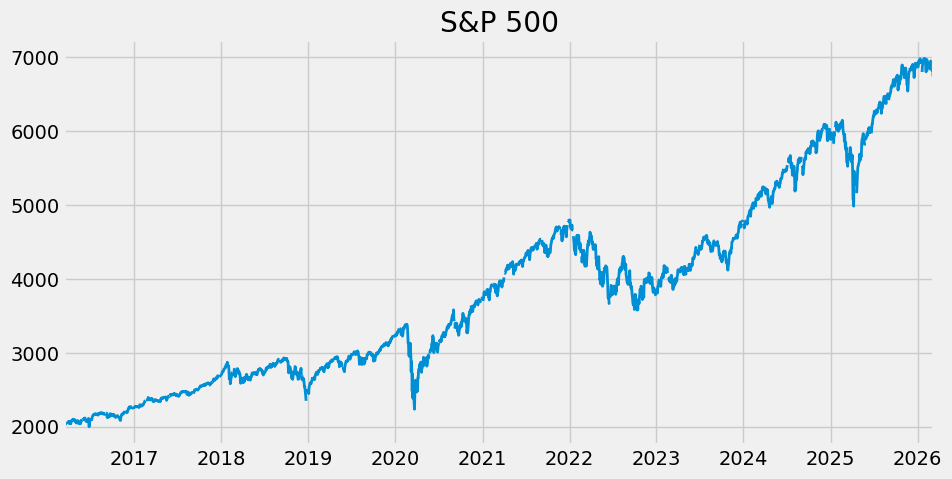

In [14]:
sp500 = fred.get_series(series_id='SP500')
sp500.plot(figsize=(10, 5), title='S&P 500', lw=2)
plt.show()

### 4. PUll and Join Multiple Data Series

In [15]:
unemp_df = fred.search('unemployment rate state', filter=('frequency','Monthly'))
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]